In [337]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline

In [338]:
df = pd.read_csv('../data/Titanic_dataset.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [339]:
#1-- Handling missing values

In [340]:
# To see the no of missing values and which features have more missing values, 2 methods are there.. 

In [341]:
#M1

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [342]:
# Age feature has 177 missing values, while cabin has 687 and embarked has only 2.

<Axes: >

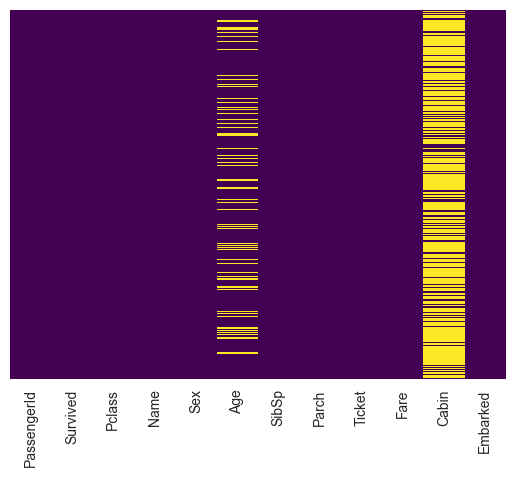

In [343]:
#M2--

sns.heatmap(df.isnull(), yticklabels= False, cbar = False, cmap= 'viridis')

In [344]:
#cbar = bar which shows the relation between colors on heatmap and numbers, cmap = color pallete(spectrum used)

#Since here the data is boolean we know 0 = purple, 1 = yellow so cbar not needed.

In [345]:
# Missing value heatmap helps us to identify patterns like-- Whenever column A has a missing value, column B also as a missing value... etc..  
# Here, we observe that age feature has values--  missing completely at random (MCAR)

In [346]:
#-- Also from both df.isnull().sum() its observed that age feature has less missing values which could be filled with mathematical calculations.
#-- But cabin feature has too many missing values so this feature might be dropped later or changed into -- cabin known(1 or 0)..

#Refer to the percentages calc in cell below-

In [347]:
#Calculating the percentages of missing values in each feature.. 

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending= False)
print(missing_percent)

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [348]:
#Analyzing the data and finding relations--

#1-- How many people survived?(countplot)
#2-- Relationship between passenger's gender and his/hers survival?(countplot with hue)
#3-- Which passenger class survived the most?(countplot with hue)
#4-- Age distribution of passengers?(displot with kde, displot without kde and histogram with matplotlib)
#5-- How many siblings/spouses were present? (countplot)
#6-- Fare distribution of passengers?(displot with kde)
#7-- How many passengers in each class?(countplot)

In [349]:
#1-- How many people survived?

C:\Users\aryan\AppData\Local\Temp\ipykernel_23420\3604227126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Survived', data = df, palette='rainbow')


<Axes: xlabel='Survived', ylabel='count'>

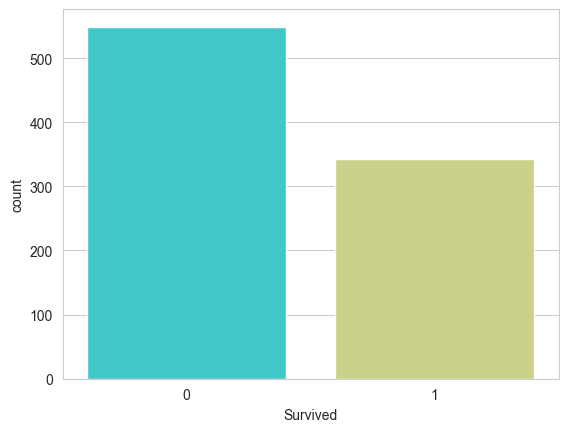

In [350]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived', data = df, palette='rainbow')

In [351]:
# Around 520 people died while around 320 survived.

In [352]:
#2-- Relationship between passenger's gender and his/hers survival?

<Axes: xlabel='Survived', ylabel='count'>

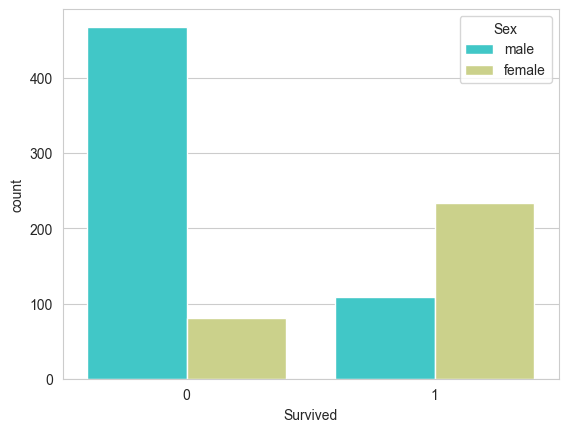

In [353]:
sns.set_style('whitegrid')
sns.countplot(x= 'Survived', hue= 'Sex', palette='rainbow', data = df)

In [354]:
# Majority of the people who died were males, which shows that females were given a higher priority than males for survival.

In [355]:
#3-- Which passenger class survived the most?

#-- pclass = 1(rich), pclass = 3(poor), pclass = 2(in between)

<Axes: xlabel='Survived', ylabel='count'>

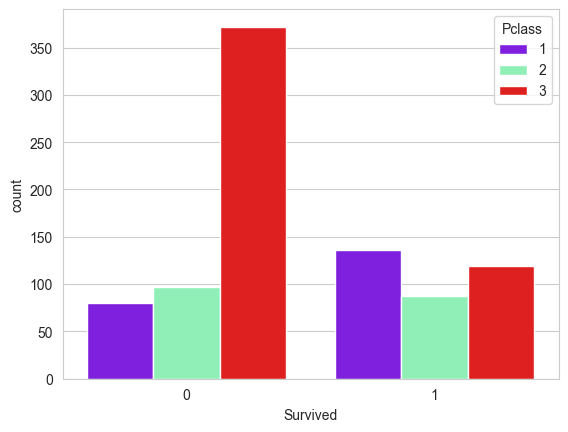

In [356]:
sns.set_style('whitegrid')
sns.countplot(data= df, x = 'Survived', hue= 'Pclass', palette='rainbow')

In [357]:
#-- Majority of people who died belonged to passenger class = 3. While majority of passenger class = 1 people survived.

In [358]:
#4-- What was the age distribution of the passengers?

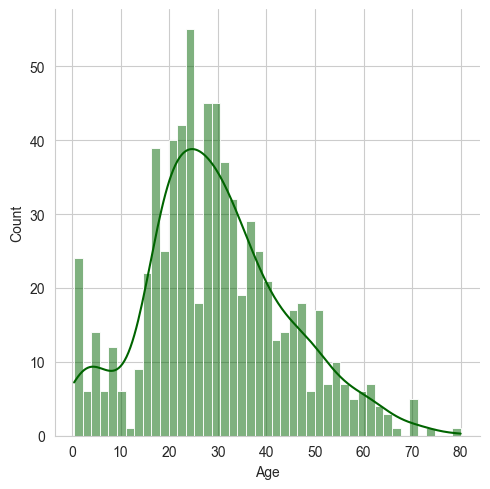

In [359]:
sns.displot(df['Age'].dropna(), bins = 45, kde = True, color = 'darkgreen') #With kernal density estimation

#Kernal density estimation is used to form the probability density function.. 

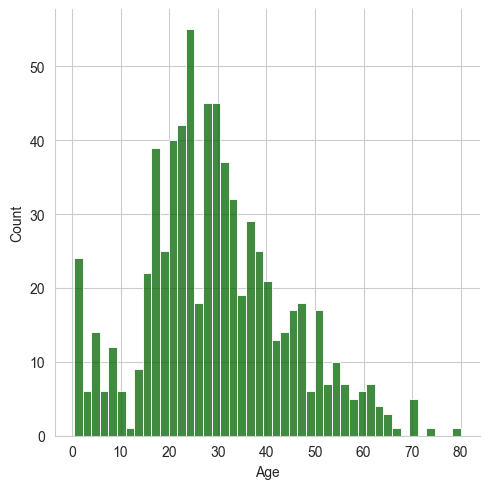

In [360]:
sns.displot(df['Age'].dropna(), bins = 45, kde = False, color = 'darkgreen') #Without kernal density estimation

<Axes: >

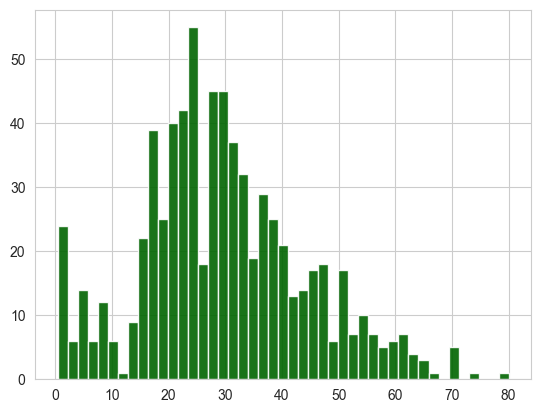

In [361]:
#Forming the same age distribution histogram using matplotlib

df['Age'].hist(bins = 45, color= 'darkgreen', alpha = 0.9)

In [362]:
# Majority of people = 20-40 years of age, there was also a spike in age distribution for children of age 0-3 years

C:\Users\aryan\AppData\Local\Temp\ipykernel_23420\217365875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= df, x= 'SibSp', palette='rainbow')


<Axes: xlabel='SibSp', ylabel='count'>

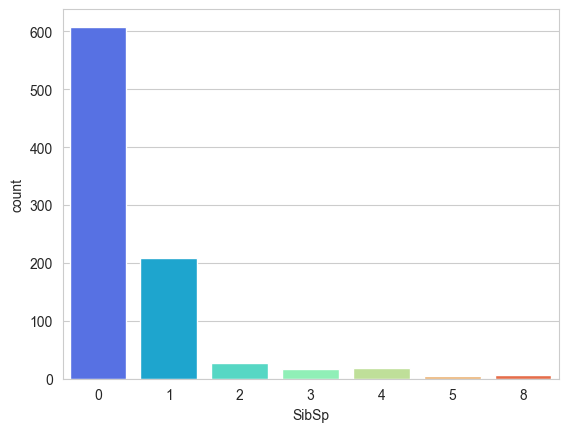

In [363]:
# 5-- How many siblings/spouses were present?

sns.set_style('whitegrid')
sns.countplot(data= df, x= 'SibSp', palette='rainbow')

#-- Majority of passengers didnt have any siblings/spouse with them. 

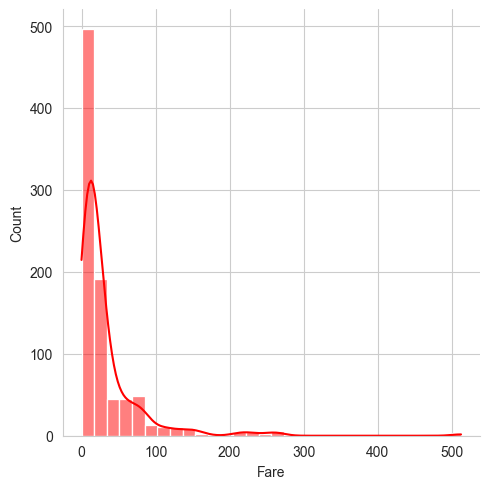

In [364]:
#6-- Analyzing the fare paid by passengers for titanic. 

sns.displot(df['Fare'], bins = 30, kde= True, color = 'red')

In [365]:
# Majority of passengers paid for cheap tickets and 3rd-class (see the next countplot to see how many passengers were there in each class)

C:\Users\aryan\AppData\Local\Temp\ipykernel_23420\749847245.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= 'Pclass', data= df, palette='rainbow')


<Axes: xlabel='Pclass', ylabel='count'>

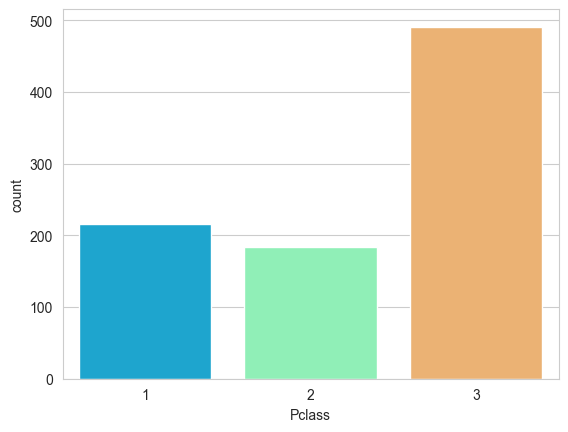

In [366]:
#7-- How many passengers were there in each class?

sns.set_style('whitegrid')
sns.countplot(x= 'Pclass', data= df, palette='rainbow')

In [367]:
#Majority of passengers were in 3rd class and hence paid for cheaper tickets. 